# AntMaze-Medium: Training Curves

Training metrics for 6 imitation learning algorithms (3 causal + 3 naive):
- **GAIL** (causal vs naive): 500 PPO rounds, 20 episodes/round
- **SQIL** (causal vs naive): 2M timesteps, SAC-based
- **IQ-Learn** (causal vs naive): 2M timesteps, SAC-based

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-medium'

# Colors: dark blue for Causal, teal for Naive
C_CAUSAL = '#5ECEDB'
C_NAIVE  = '#9440A2'

def smooth(y, window=10):
    """Simple moving average."""
    if len(y) < window:
        return y
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

## Data (extracted from training notebook outputs)

In [2]:
# ============================================================
# GAIL  (logged every 10 rounds, 500 total)
# ============================================================
gail_iters = np.arange(10, 501, 10)

cgail_return = np.array([
    -356.55,-376.58,-392.23,-304.62,-309.03,-343.65,-330.58,-288.00,-281.93,-325.76,
    -294.28,-230.33,-292.16,-287.87,-260.15,-269.44,-261.38,-245.74,-213.38,-181.00,
    -222.59,-262.98,-283.39,-224.68,-273.07,-259.53,-221.54,-188.09,-178.29,-225.63,
    -218.41,-239.46,-230.94,-215.38,-186.50,-167.39,-204.70,-218.67,-190.45,-155.93,
    -171.60,-179.03,-195.69,-174.11,-212.44,-153.74,-184.42,-230.20,-152.75,-217.35,
])

cgail_dloss = np.array([
    0.202,0.285,0.325,0.343,0.401,0.378,0.413,0.505,0.552,0.550,
    0.632,0.681,0.730,0.725,0.728,0.715,0.739,0.770,0.737,0.797,
    0.811,0.763,0.766,0.811,0.760,0.835,0.835,0.878,0.871,0.833,
    0.842,0.827,0.846,0.844,0.936,0.886,0.863,0.851,0.905,0.903,
    0.937,0.934,0.854,0.914,0.892,0.917,0.938,0.870,0.969,0.897,
])

cgail_actor_loss = np.array([
    -0.124,-0.116,-0.115,-0.112,-0.110,-0.107,-0.108,-0.105,-0.101,-0.100,
    -0.099,-0.099,-0.095,-0.098,-0.102,-0.097,-0.095,-0.092,-0.098,-0.089,
    -0.088,-0.093,-0.081,-0.094,-0.080,-0.094,-0.086,-0.076,-0.079,-0.075,
    -0.090,-0.088,-0.066,-0.073,-0.074,-0.050,-0.096,-0.061,-0.076,-0.061,
    -0.073,-0.055,-0.071,-0.064,-0.073,-0.069,-0.067,-0.058,-0.087,-0.053,
])

ngail_return = np.array([
    -349.16,-337.59,-308.29,-294.28,-320.67,-312.28,-276.89,-256.82,-278.99,-246.23,
    -248.05,-247.99,-260.95,-193.48,-185.34,-221.21,-232.99,-252.30,-240.00,-171.81,
    -223.75,-192.00,-217.65,-207.28,-172.31,-182.18,-219.31,-180.32,-159.38,-166.11,
    -194.01,-200.60,-209.59,-209.67,-208.30,-215.07,-187.52,-176.54,-202.38,-214.16,
    -212.86,-143.40,-181.41,-171.49,-141.53,-150.17,-195.60,-151.58,-161.67,-164.96,
])

ngail_dloss = np.array([
    0.189,0.270,0.327,0.410,0.426,0.518,0.560,0.621,0.634,0.673,
    0.648,0.695,0.677,0.709,0.745,0.737,0.778,0.727,0.755,0.842,
    0.776,0.805,0.847,0.847,0.843,0.878,0.809,0.830,0.868,0.913,
    0.893,0.920,0.914,0.901,0.911,0.900,0.881,0.915,0.901,0.891,
    0.936,0.973,0.934,0.979,0.963,0.947,0.910,0.990,0.988,0.999,
])

ngail_actor_loss = np.array([
    -0.125,-0.117,-0.112,-0.109,-0.111,-0.108,-0.108,-0.105,-0.108,-0.108,
    -0.106,-0.106,-0.102,-0.101,-0.097,-0.095,-0.073,-0.089,-0.088,-0.071,
    -0.084,-0.059,-0.047,-0.083,-0.046,-0.048,-0.068,-0.033,-0.048, 0.056,
    -0.100,-0.035,-0.022,-0.021,-0.039,-0.019,-0.026, 0.003,-0.015,-0.021,
    -0.036,-0.032,-0.030,-0.052,-0.013,-0.015,-0.021,-0.042,-0.057,-0.061,
])

In [3]:
# ============================================================
# SQIL  (logged every 50 episodes)  — from out_csqil_antmed2 / out_nsqil_antmed2
# ============================================================

csqil_ts = np.array([
    50000,99123,144322,186168,235304,285304,335304,383947,425161,464040,
    501100,539488,581179,617725,652552,688098,729768,763679,800629,832754,
    875789,918093,967615,1014986,1045091,1072800,1098261,1129422,1159947,1190717,
    1219790,1251523,1291966,1330539,1364831,1407639,1437288,1466309,1492869,1538213,
    1588213,1638213,1687893,1734868,1782623,1829924,1870139,1918317,1962844,
])
csqil_eval = np.array([
    -323.72,-255.58,-197.31,-212.59,-362.27,-349.70,-308.27,-232.26,-230.61,-85.10,
    -249.28,-181.71,-222.46,-203.81,-166.15,-260.19,-127.60,-185.72,-185.18,-285.22,
    -181.18,-366.18,-242.55,-122.90,-98.50,-95.51,-79.32,-142.50,-91.78,-148.83,
    -163.62,-141.22,-241.76,-175.86,-146.58,-145.42,-143.07,-212.69,-55.65,-369.91,
    -338.08,-314.25,-252.16,-280.30,-241.36,-229.08,-210.60,-330.58,-190.07,
])
csqil_train = np.array([
    -413.42,-93.32,-96.09,-72.00,-425.89,-261.15,-331.16,-90.22,-356.51,-70.33,
    -286.40,-17.57,-412.36,-59.62,-24.60,-82.18,-188.65,-147.15,-34.72,-252.70,
    -110.55,-573.50,-203.52,-257.53,-52.18,-168.40,-87.98,-223.21,-132.41,-248.35,
    -167.12,-267.02,-346.32,-82.92,-421.17,-315.83,-385.38,-423.51,-56.58,-251.32,
    -368.14,-232.70,-127.67,-197.87,-213.50,-344.05,-337.92,-479.92,-60.17,
])
csqil_alpha = np.array([
    0.0240,0.0237,0.0246,0.0256,0.1000,0.0353,0.0148,0.0163,0.0165,0.0175,
    0.0186,0.0180,0.0196,0.0198,0.0200,0.0215,0.0217,0.0219,0.0232,0.0252,
    0.0256,0.0241,0.0246,0.0244,0.0234,0.0249,0.0258,0.0259,0.0257,0.0264,
    0.0261,0.0271,0.0270,0.0277,0.0264,0.0253,0.0257,0.0257,0.0272,0.0176,
    0.0186,0.0277,0.0213,0.0213,0.0217,0.0222,0.0238,0.0200,0.0215,
])

nsqil_ts = np.array([
    49619,97394,138497,179930,220822,257807,290400,321300,352969,381931,
    409795,435312,465617,497300,523061,550650,577188,604301,632408,661631,
    685396,711887,742573,767774,799226,828491,857231,888405,915592,943061,
    971498,998034,1026390,1051777,1075771,1103202,1135913,1166451,1196656,1222851,
    1253637,1276988,1306555,1337519,1365369,1398859,1426807,1455653,1483456,1511547,
    1538389,1566178,1593068,1619858,1646353,1676316,1703638,1734518,1763012,1790326,
    1814081,1840422,1865533,1892968,1924245,1951880,1983526,
])
nsqil_eval = np.array([
    -298.61,-249.36,-129.49,-128.69,-135.30,-187.70,-125.12,-170.61,-136.31,-110.93,
    -166.75,-137.86,-111.11,-61.68,-136.40,-88.90,-127.33,-112.59,-115.03,-105.29,
    -95.80,-103.42,-120.07,-136.96,-108.90,-49.84,-132.57,-158.13,-101.40,-104.47,
    -118.18,-117.55,-110.89,-74.89,-143.29,-125.63,-176.60,-164.22,-92.63,-194.39,
    -107.35,-135.75,-163.27,-158.95,-140.34,-213.24,-138.66,-93.65,-198.61,-103.76,
    -190.86,-106.77,-99.77,-78.37,-74.08,-153.16,-105.53,-314.81,-136.06,-217.75,
    -170.77,-71.92,-158.13,-115.39,-202.31,-84.78,-102.87,
])
nsqil_train = np.array([
    -396.54,-413.77,-267.70,-323.44,-244.77,-128.06,-172.18,-201.00,-64.47,-451.78,
    -67.38,-384.36,-120.19,-236.12,-72.05,-66.31,-49.99,-28.47,-28.54,-59.24,
    -114.23,-16.25,-288.74,-100.07,-264.31,-225.59,-58.51,-165.30,-77.11,-84.86,
    -210.63,-405.32,-91.94,-95.20,-58.22,-15.42,-48.56,-279.78,-260.10,-107.35,
    -27.82,-72.33,-269.25,-24.27,-121.47,-298.49,-199.91,-213.90,-68.40,-54.94,
    -228.48,-447.54,-175.88,-348.72,-259.95,-164.74,-74.92,-114.58,2.00,-226.02,
    -112.10,-25.13,-54.62,-20.45,-61.93,-353.65,-373.81,
])
nsqil_alpha = np.array([
    0.0240,0.0232,0.0242,0.0242,0.0244,0.0246,0.0242,0.0253,0.0268,0.0263,
    0.0270,0.0271,0.0285,0.0289,0.0296,0.0309,0.0304,0.0309,0.0327,0.0338,
    0.0351,0.0351,0.0366,0.0371,0.0375,0.0381,0.0377,0.0389,0.0386,0.0391,
    0.0397,0.0404,0.0407,0.0408,0.0411,0.0403,0.0412,0.0417,0.0410,0.0418,
    0.0409,0.0412,0.0404,0.0402,0.0411,0.0405,0.0402,0.0406,0.0404,0.0392,
    0.0399,0.0404,0.0397,0.0410,0.0404,0.0404,0.0407,0.0402,0.0402,0.0410,
    0.0421,0.0417,0.0408,0.0397,0.0413,0.0415,0.0409,
])

In [4]:
# ============================================================
# IQ-Learn  (logged every 50 episodes)  — from out_ciqlearn_antmed2 / out_niqlearn_antmed2
# ============================================================

ciq_ts = np.array([
    50000,99850,147215,194426,239872,285745,322992,357512,389097,420345,
    456194,489153,522820,551906,577231,603745,629238,654422,679436,703233,
    729580,756477,801987,831022,858034,887211,912683,939925,975652,1025652,
    1075652,1115233,1150741,1186930,1213224,1243825,1273426,1299347,1320471,1343807,
    1366703,1393009,1432408,1481600,1523488,1550608,1579520,1608850,1630989,1660788,
    1684996,1709523,1735083,1755325,1776858,1795998,1817629,1838697,1858911,1880878,
    1902591,1922815,1942737,1965343,1987631,
])
ciq_eval = np.array([
    -331.25,-291.63,-233.07,-247.42,-176.97,-164.89,-174.34,-111.05,-134.17,-144.29,
    -109.41,-168.68,-111.21,-96.92,-148.12,-80.59,-183.26,-105.18,-150.12,-110.77,
    -115.89,-311.11,-116.85,-145.18,-177.17,-128.97,-150.36,-160.71,-378.82,-320.28,
    -248.23,-154.56,-232.78,-202.66,-142.57,-47.91,-60.35,-122.61,-91.31,-78.75,
    -70.24,-112.77,-301.98,-251.23,-143.80,-113.20,-67.50,-68.97,-84.19,-105.28,
    -76.66,-96.53,-78.05,-65.54,-60.29,-78.90,-73.43,-118.25,-53.22,-126.28,
    -111.61,-127.96,-49.88,-71.44,-67.60,
])
ciq_train = np.array([
    -228.41,-306.16,-176.25,-153.87,-100.09,-267.48,2.00,-170.71,-76.73,-379.69,
    -379.25,-268.64,-77.26,-90.07,-40.90,-25.95,-148.65,-154.84,-86.14,-227.65,
    -345.13,-371.22,-138.77,-47.46,-184.99,-106.36,-53.94,-125.45,-449.88,-344.61,
    -284.60,-113.43,-356.46,-370.81,-86.69,-112.76,-114.43,-98.81,-89.49,-158.12,
    -26.89,-176.19,-272.18,-203.36,-421.66,-169.20,-155.54,-517.77,-366.58,-107.44,
    -127.48,-83.95,-254.53,2.00,-48.38,-77.19,-124.80,-68.31,-39.83,-74.40,
    -130.68,-137.14,-33.49,-72.12,-271.31,
])
ciq_alpha = np.array([
    0.0197,0.0303,0.0337,0.0375,0.0406,0.0417,0.0411,0.0418,0.0416,0.0411,
    0.0432,0.0431,0.0443,0.0452,0.0458,0.0457,0.0460,0.0487,0.0491,0.0507,
    0.0538,0.0519,0.0553,0.0564,0.0585,0.0604,0.0607,0.0607,0.0533,0.0560,
    0.0604,0.0634,0.0623,0.0618,0.0602,0.0617,0.0623,0.0627,0.0640,0.0651,
    0.0655,0.0673,0.0564,0.0648,0.0671,0.0659,0.0662,0.0656,0.0668,0.0671,
    0.0685,0.0693,0.0689,0.0700,0.0695,0.0696,0.0688,0.0691,0.0692,0.0689,
    0.0689,0.0685,0.0690,0.0688,0.0697,
])

niq_ts = np.array([
    50000,99466,146048,191470,237745,277223,314659,345212,381035,419237,
    455986,483498,516569,549174,579938,605005,629801,660839,688081,711953,
    737083,767366,797743,823912,850848,880492,907264,935804,969763,999073,
    1026189,1055122,1081995,1104361,1127409,1150049,1177240,1199421,1226267,1249039,
    1272887,1299284,1327073,1354137,1383294,1408511,1434854,1461902,1484627,1511766,
    1535481,1562225,1588738,1615059,1642358,1665809,1694550,1717104,1739960,1762152,
    1788573,1815098,1839499,1861661,1883344,1909524,1933627,1962570,1989562,
])
niq_eval = np.array([
    -301.93,-274.67,-252.65,-205.01,-264.16,-162.92,-245.14,-194.97,-174.93,-157.08,
    -137.98,-172.40,-158.99,-145.99,-159.22,-73.19,-150.26,-172.14,-83.79,-109.76,
    -163.42,-129.20,-76.44,-107.99,-48.78,-131.41,-129.51,-164.41,-131.75,-118.57,
    -132.81,-75.66,-111.94,-79.45,-69.14,-43.30,-46.90,-49.35,-82.47,-155.38,
    -78.40,-203.37,-136.95,-88.90,-140.64,-123.68,-128.74,-102.33,-74.81,-99.33,
    -129.37,-70.22,-168.66,-88.44,-87.68,-127.94,-112.26,-53.75,-70.32,-99.74,
    -53.31,-124.07,-77.26,-97.86,-108.25,-112.98,-117.36,-97.26,-130.40,
])
niq_train = np.array([
    -98.33,-422.05,-380.98,-478.08,-154.66,-226.21,-22.13,-91.82,-202.74,-138.71,
    -214.42,-200.45,-35.10,-50.02,-105.01,-28.71,-66.80,-49.58,-237.42,-152.36,
    -52.76,-126.90,-60.12,-128.35,-136.85,-172.54,-49.46,-130.91,-80.65,-24.31,
    -128.69,-84.05,-103.30,-357.12,-360.63,-110.02,-13.61,-192.81,-65.95,-212.38,
    -368.29,-23.29,-97.28,-280.50,-63.08,-198.96,-106.17,-110.54,-38.51,-192.68,
    -56.84,-70.09,-43.68,-70.69,-417.91,-356.68,-74.66,-206.46,-53.57,-43.14,
    -389.83,-273.76,-507.49,-118.93,-158.03,-134.11,-58.46,-113.03,-109.42,
])
niq_alpha = np.array([
    0.0227,0.0286,0.0357,0.0389,0.0355,0.0374,0.0363,0.0379,0.0377,0.0390,
    0.0412,0.0428,0.0444,0.0455,0.0483,0.0490,0.0501,0.0516,0.0540,0.0553,
    0.0586,0.0610,0.0609,0.0637,0.0656,0.0675,0.0689,0.0714,0.0714,0.0753,
    0.0732,0.0748,0.0743,0.0753,0.0773,0.0781,0.0780,0.0794,0.0787,0.0797,
    0.0797,0.0821,0.0832,0.0835,0.0831,0.0833,0.0826,0.0832,0.0828,0.0846,
    0.0848,0.0842,0.0858,0.0846,0.0844,0.0838,0.0840,0.0848,0.0850,0.0855,
    0.0849,0.0848,0.0846,0.0844,0.0842,0.0833,0.0841,0.0834,0.0844,
])

---
## 1. GAIL Training Curves

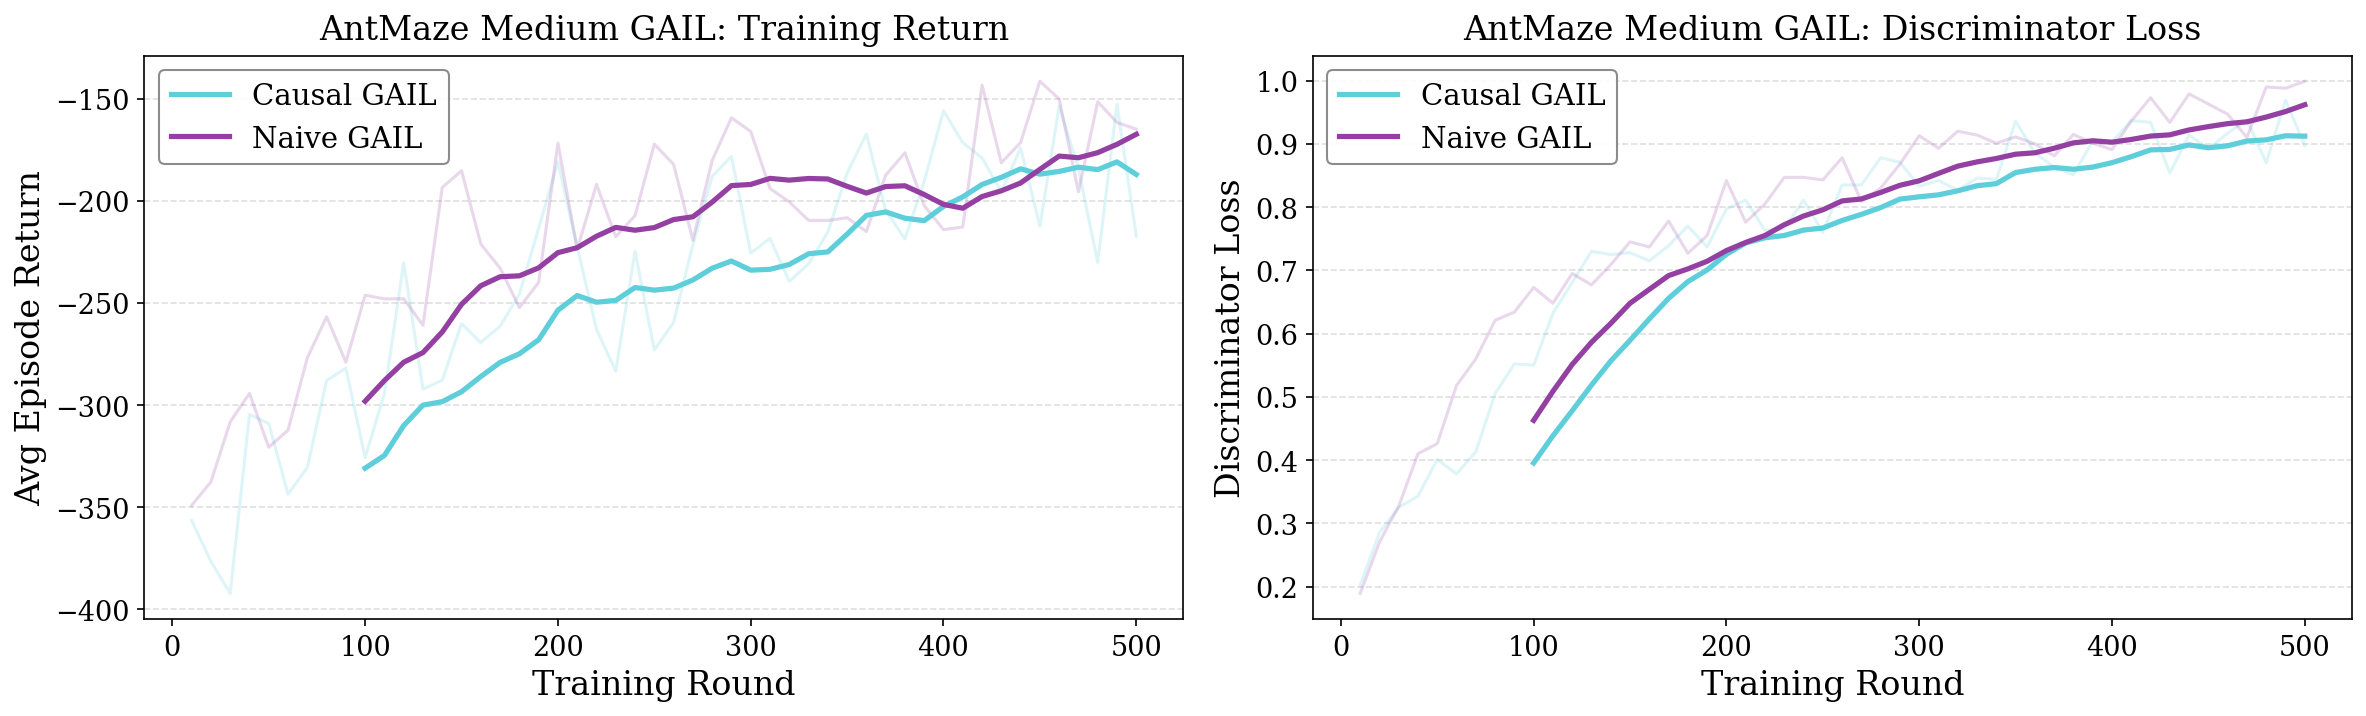

In [5]:
W = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(gail_iters, cgail_return, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_return, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_return, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_return, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('Avg Episode Return')
ax.set_title('AntMaze Medium GAIL: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(gail_iters, cgail_dloss, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_dloss, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_dloss, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_dloss, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('Discriminator Loss')
ax.set_title('AntMaze Medium GAIL: Discriminator Loss', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_gail_return_dloss.pdf', dpi=300, bbox_inches='tight')
plt.show()

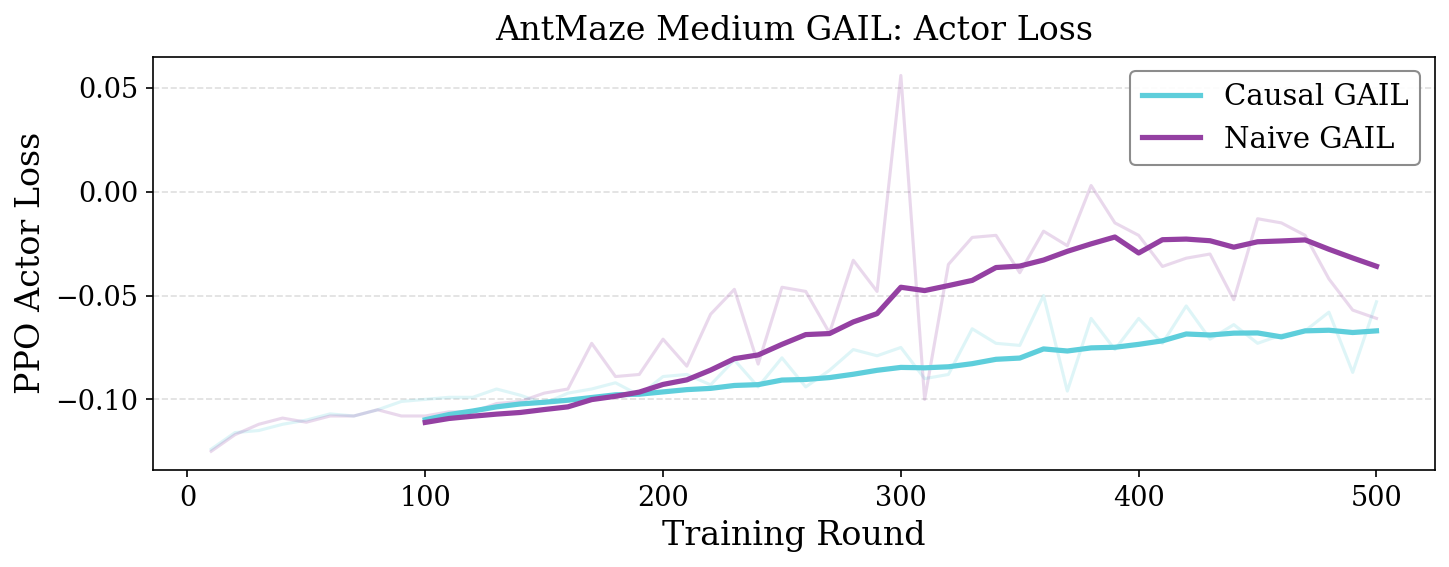

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gail_iters, cgail_actor_loss, alpha=0.2, color=C_CAUSAL)
ax.plot(gail_iters, ngail_actor_loss, alpha=0.2, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_actor_loss, W), linewidth=2.5, color=C_CAUSAL, label='Causal GAIL')
ax.plot(gail_iters[W-1:], smooth(ngail_actor_loss, W), linewidth=2.5, color=C_NAIVE, label='Naive GAIL')
ax.set_xlabel('Training Round')
ax.set_ylabel('PPO Actor Loss')
ax.set_title('AntMaze Medium GAIL: Actor Loss', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_gail_actor_loss.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 2. SQIL Training Curves

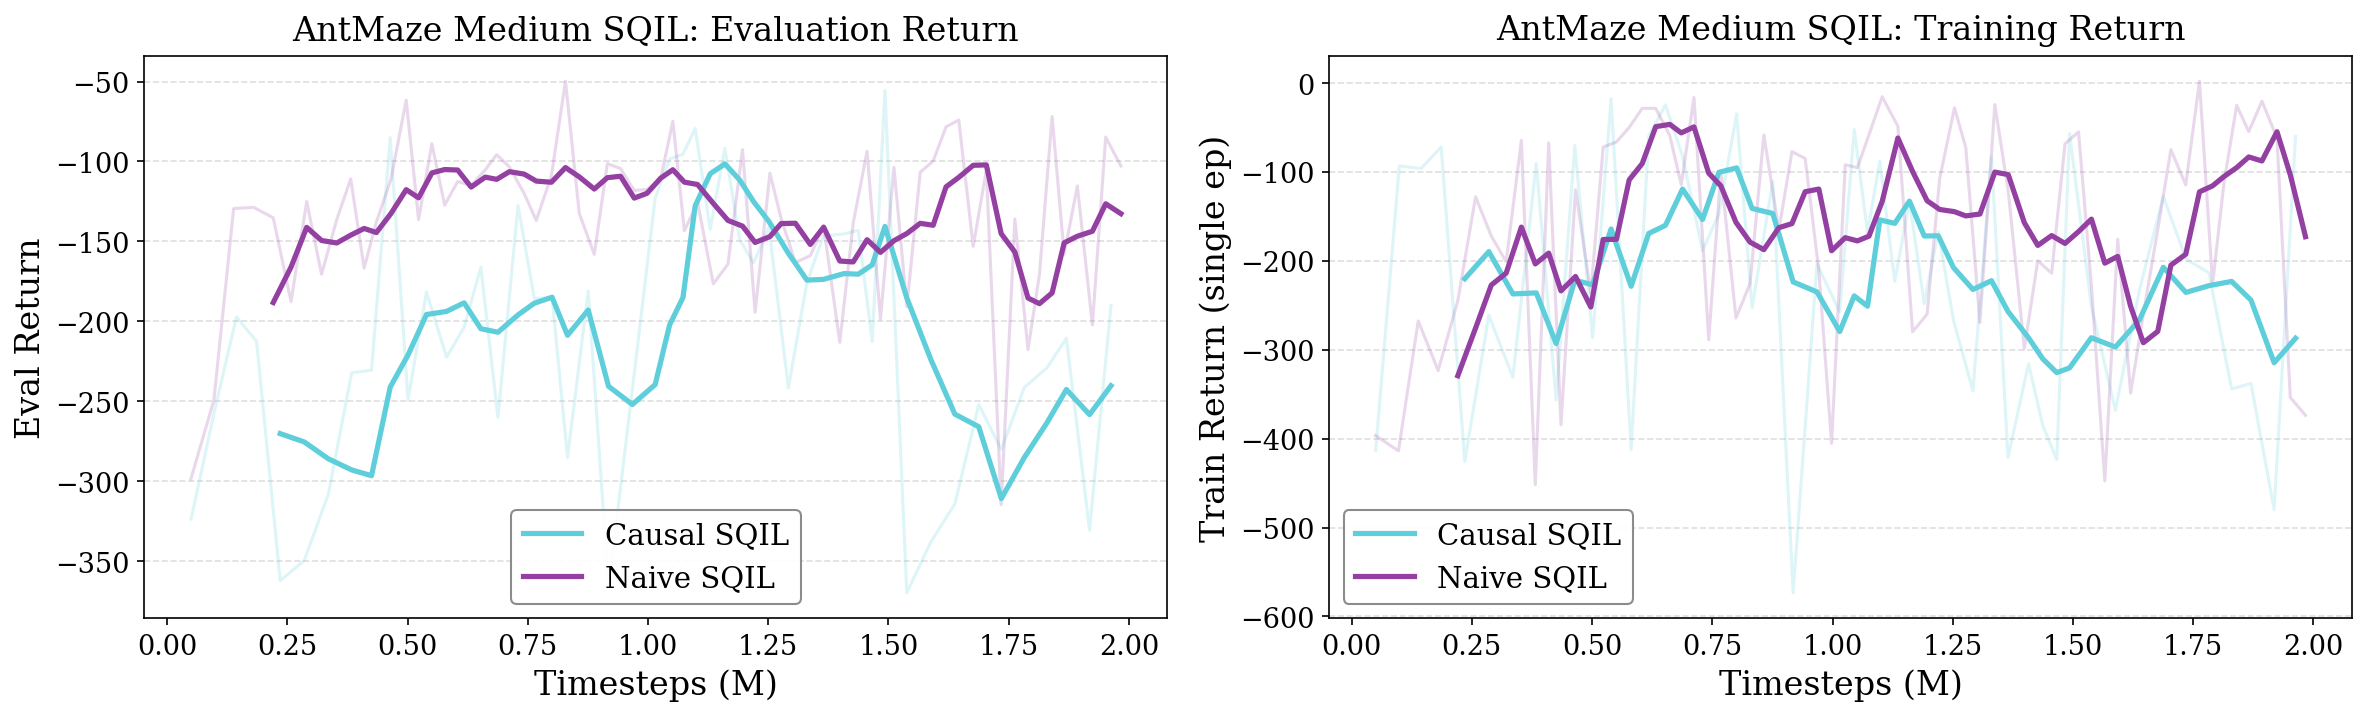

In [7]:
W_sac = 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(csqil_ts / 1e6, csqil_eval, alpha=0.2, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_eval, alpha=0.2, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Medium SQIL: Evaluation Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(csqil_ts / 1e6, csqil_train, alpha=0.2, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_train, alpha=0.2, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_train, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_train, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Train Return (single ep)')
ax.set_title('AntMaze Medium SQIL: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_sqil_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

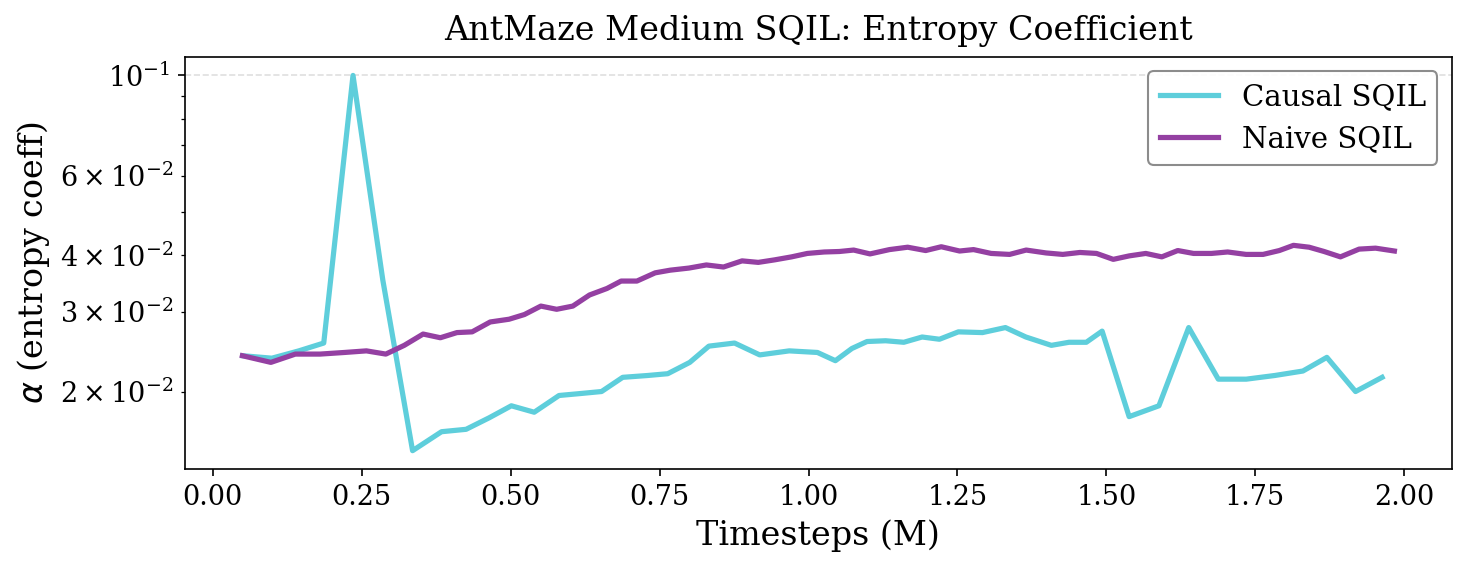

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(csqil_ts / 1e6, csqil_alpha, linewidth=2.5, color=C_CAUSAL, label='Causal SQIL')
ax.plot(nsqil_ts / 1e6, nsqil_alpha, linewidth=2.5, color=C_NAIVE, label='Naive SQIL')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('$\\alpha$ (entropy coeff)')
ax.set_title('AntMaze Medium SQIL: Entropy Coefficient', pad=8)
ax.set_yscale('log')
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_sqil_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 3. IQ-Learn Training Curves

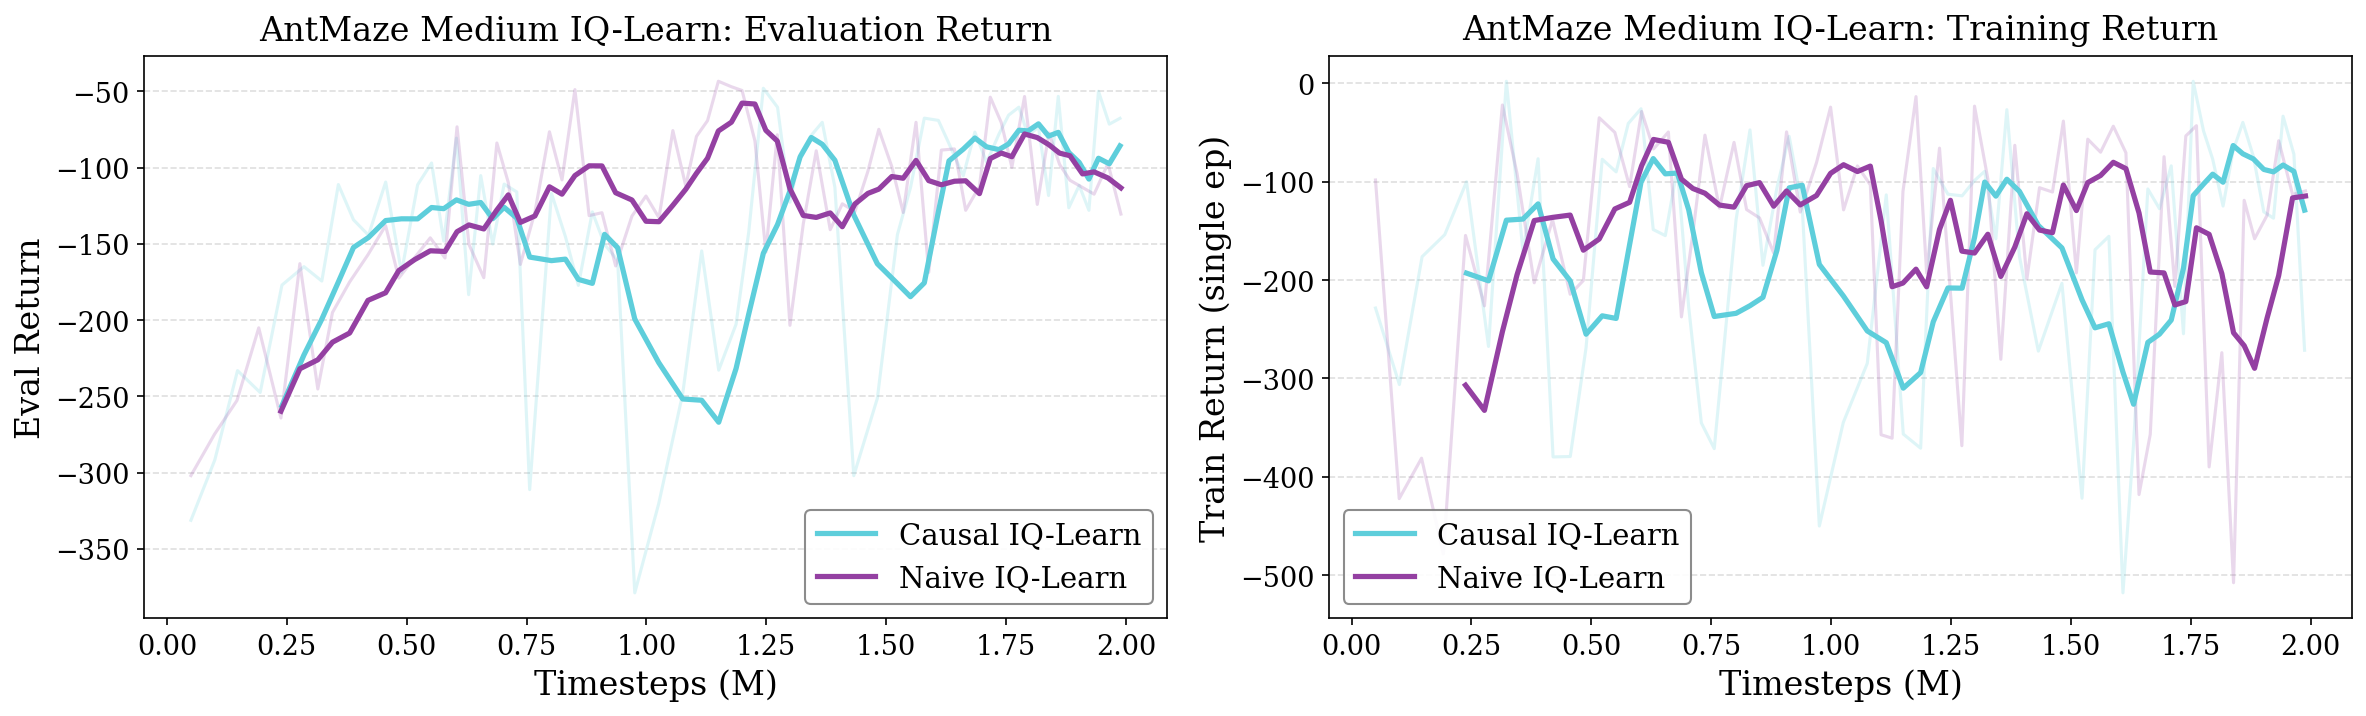

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ciq_ts / 1e6, ciq_eval, alpha=0.2, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_eval, alpha=0.2, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Medium IQ-Learn: Evaluation Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(ciq_ts / 1e6, ciq_train, alpha=0.2, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_train, alpha=0.2, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_train, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_train, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Train Return (single ep)')
ax.set_title('AntMaze Medium IQ-Learn: Training Return', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_iqlearn_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

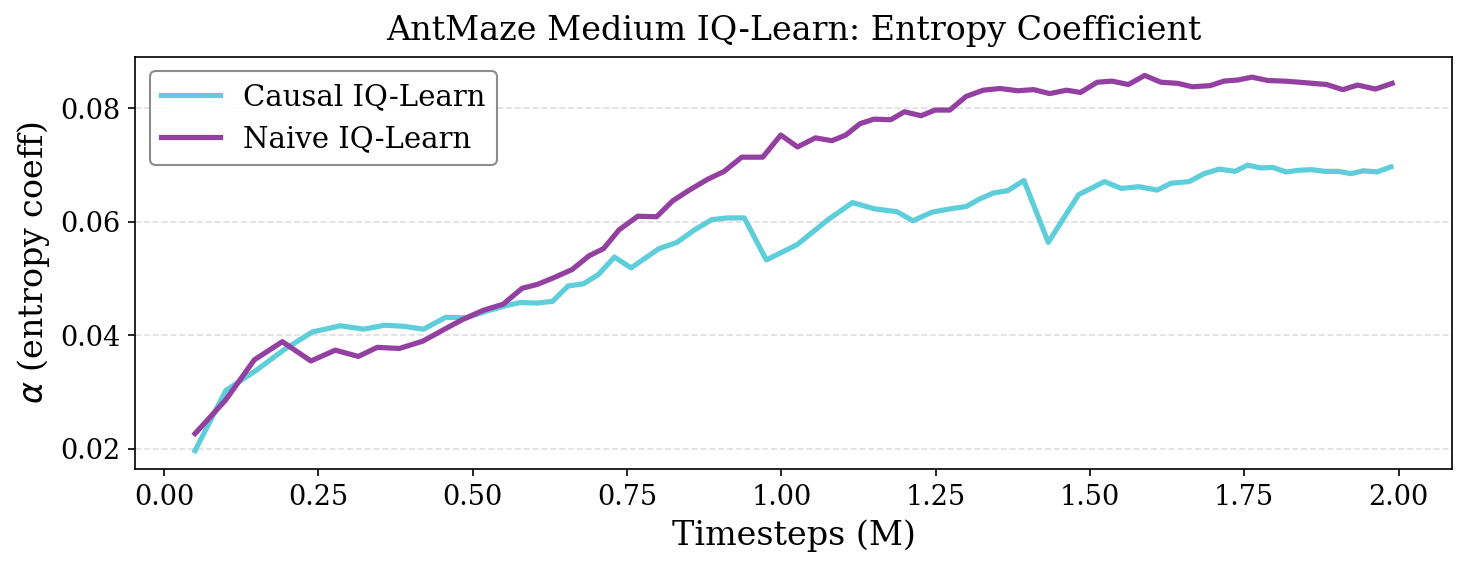

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ciq_ts / 1e6, ciq_alpha, linewidth=2.5, color=C_CAUSAL, label='Causal IQ-Learn')
ax.plot(niq_ts / 1e6, niq_alpha, linewidth=2.5, color=C_NAIVE, label='Naive IQ-Learn')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('$\\alpha$ (entropy coeff)')
ax.set_title('AntMaze Medium IQ-Learn: Entropy Coefficient', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_iqlearn_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Combined: All Algorithms Eval Return

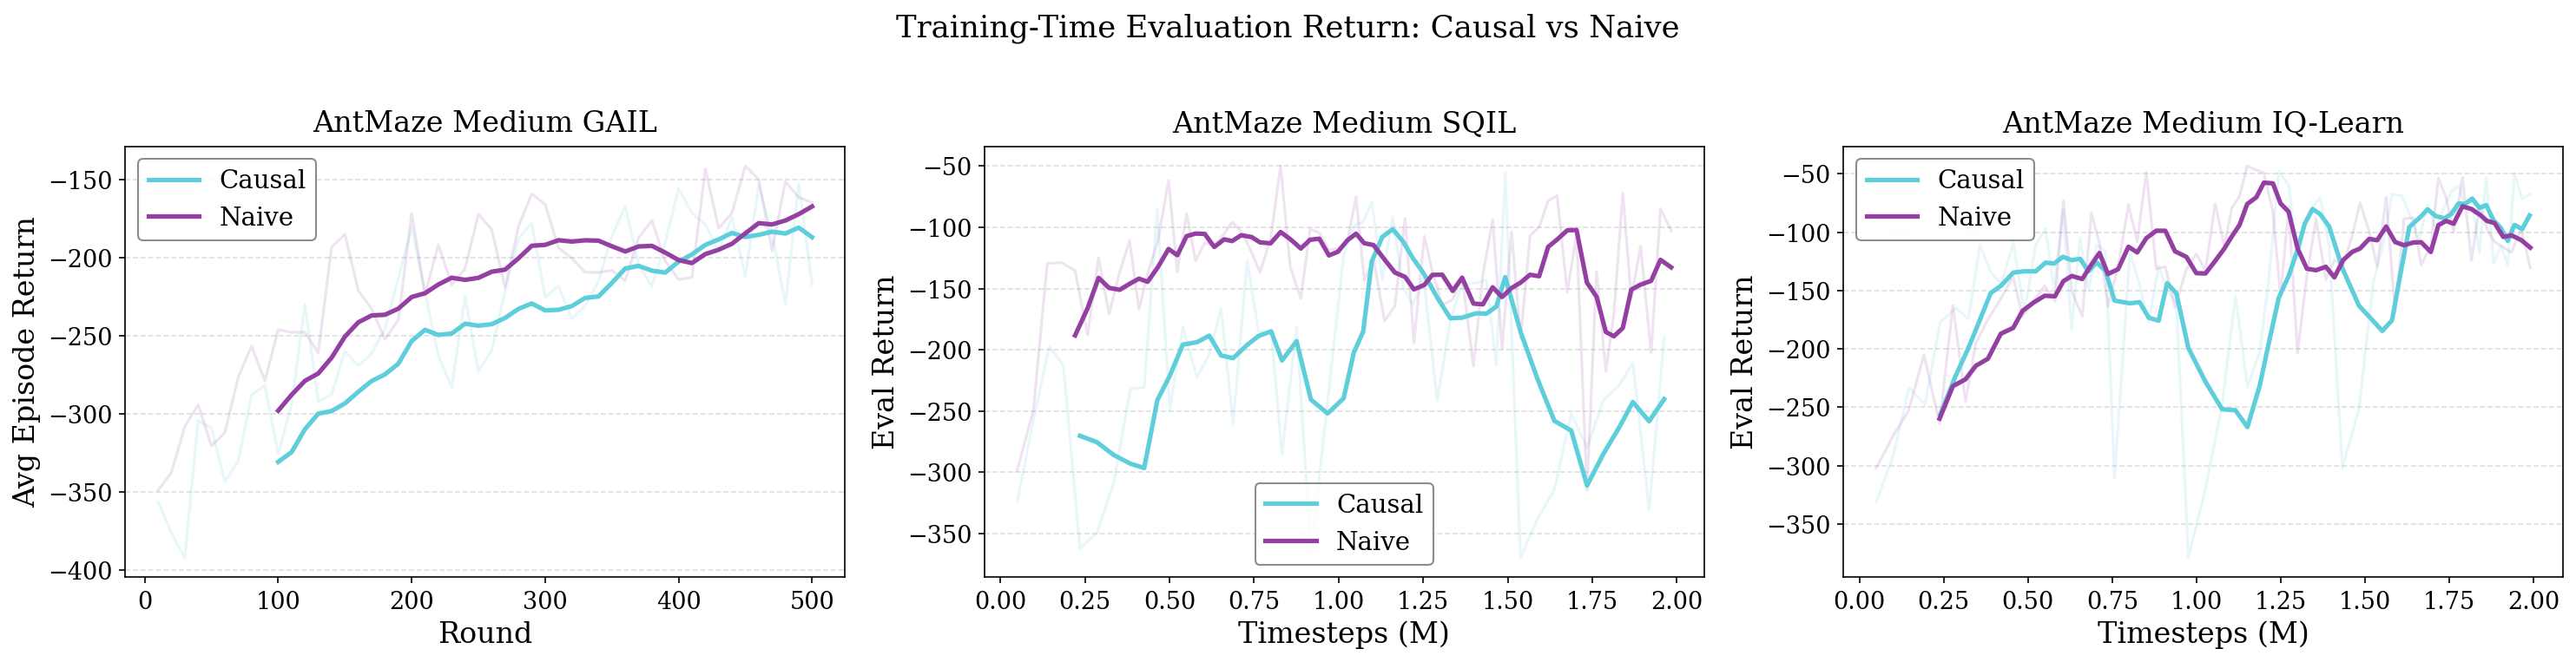

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.plot(gail_iters, cgail_return, alpha=0.15, color=C_CAUSAL)
ax.plot(gail_iters, ngail_return, alpha=0.15, color=C_NAIVE)
ax.plot(gail_iters[W-1:], smooth(cgail_return, W), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(gail_iters[W-1:], smooth(ngail_return, W), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Round')
ax.set_ylabel('Avg Episode Return')
ax.set_title('AntMaze Medium GAIL', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[1]
ax.plot(csqil_ts / 1e6, csqil_eval, alpha=0.15, color=C_CAUSAL)
ax.plot(nsqil_ts / 1e6, nsqil_eval, alpha=0.15, color=C_NAIVE)
ax.plot(csqil_ts[W_sac-1:] / 1e6, smooth(csqil_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(nsqil_ts[W_sac-1:] / 1e6, smooth(nsqil_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Medium SQIL', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

ax = axes[2]
ax.plot(ciq_ts / 1e6, ciq_eval, alpha=0.15, color=C_CAUSAL)
ax.plot(niq_ts / 1e6, niq_eval, alpha=0.15, color=C_NAIVE)
ax.plot(ciq_ts[W_sac-1:] / 1e6, smooth(ciq_eval, W_sac), linewidth=2.5, color=C_CAUSAL, label='Causal')
ax.plot(niq_ts[W_sac-1:] / 1e6, smooth(niq_eval, W_sac), linewidth=2.5, color=C_NAIVE, label='Naive')
ax.set_xlabel('Timesteps (M)')
ax.set_ylabel('Eval Return')
ax.set_title('AntMaze Medium IQ-Learn', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.suptitle('Training-Time Evaluation Return: Causal vs Naive', fontsize=17, y=1.02)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_combined_eval_return.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Combined: All Causal Algorithms

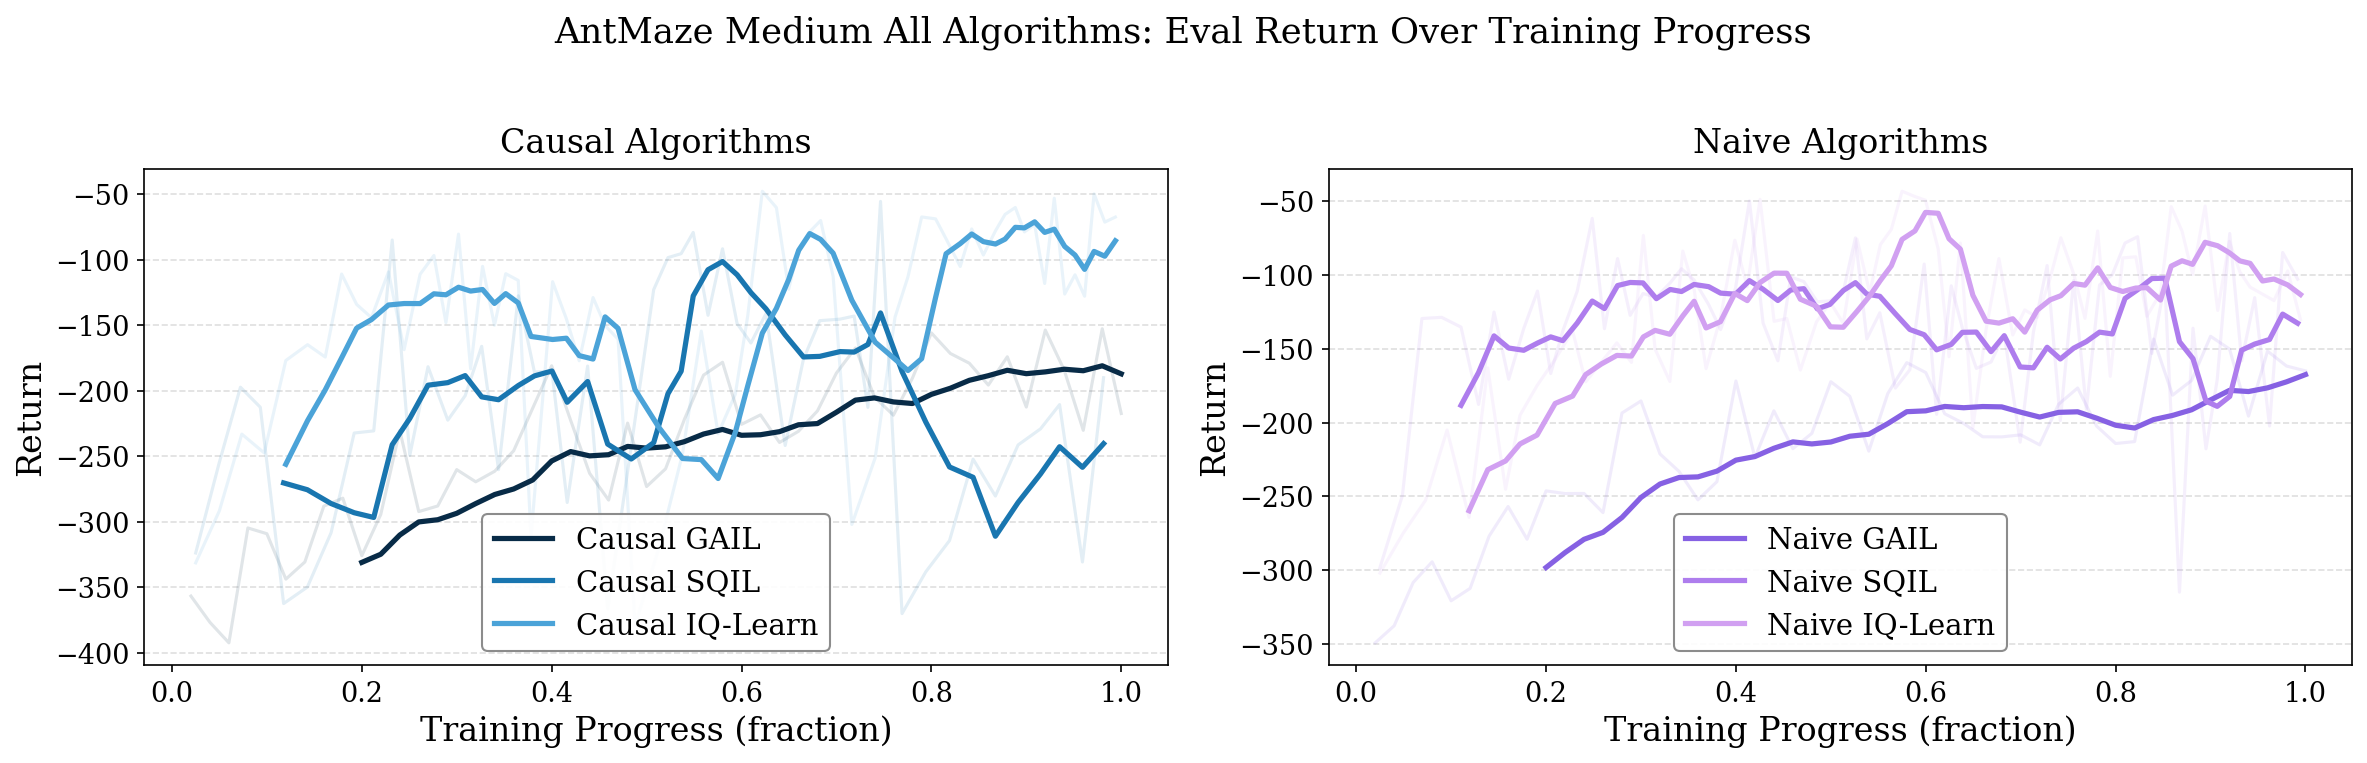

In [12]:
# Colors for multi-algorithm overlay (3 distinguishable blues)
C_GAIL = '#082B47'    # darkest
C_SQIL = '#1976B0'    # medium
C_IQL  = '#4BA3D8'    # lighter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(gail_iters / 500, cgail_return, alpha=0.12, color=C_GAIL)
ax.plot(csqil_ts / 2e6, csqil_eval, alpha=0.12, color=C_SQIL)
ax.plot(ciq_ts / 2e6, ciq_eval, alpha=0.12, color=C_IQL)
ax.plot(gail_iters[W-1:] / 500, smooth(cgail_return, W), linewidth=2.5, color=C_GAIL, label='Causal GAIL')
ax.plot(csqil_ts[W_sac-1:] / 2e6, smooth(csqil_eval, W_sac), linewidth=2.5, color=C_SQIL, label='Causal SQIL')
ax.plot(ciq_ts[W_sac-1:] / 2e6, smooth(ciq_eval, W_sac), linewidth=2.5, color=C_IQL, label='Causal IQ-Learn')
ax.set_xlabel('Training Progress (fraction)')
ax.set_ylabel('Return')
ax.set_title('Causal Algorithms', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Lighter palette for naive
C_GAIL_N = "#8661E3"
C_SQIL_N = "#AE7DED"
C_IQL_N  = "#D1A0F1"

ax = axes[1]
ax.plot(gail_iters / 500, ngail_return, alpha=0.12, color=C_GAIL_N)
ax.plot(nsqil_ts / 2e6, nsqil_eval, alpha=0.12, color=C_SQIL_N)
ax.plot(niq_ts / 2e6, niq_eval, alpha=0.12, color=C_IQL_N)
ax.plot(gail_iters[W-1:] / 500, smooth(ngail_return, W), linewidth=2.5, color=C_GAIL_N, label='Naive GAIL')
ax.plot(nsqil_ts[W_sac-1:] / 2e6, smooth(nsqil_eval, W_sac), linewidth=2.5, color=C_SQIL_N, label='Naive SQIL')
ax.plot(niq_ts[W_sac-1:] / 2e6, smooth(niq_eval, W_sac), linewidth=2.5, color=C_IQL_N, label='Naive IQ-Learn')
ax.set_xlabel('Training Progress (fraction)')
ax.set_ylabel('Return')
ax.set_title('Naive Algorithms', pad=8)
ax.legend(framealpha=0.9, edgecolor='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.suptitle('AntMaze Medium All Algorithms: Eval Return Over Training Progress', fontsize=17, y=1.02)
plt.tight_layout()
fig.savefig(f'{PLOTS_DIR}/antmed_training_all_algorithms_progress.pdf', dpi=300, bbox_inches='tight')
plt.show()